# Decision Tree Construction with the ID3 Algorithm

This notebook builds decision trees **from scratch** using *entropy* and *information gain*,
reproducing the calculations from the lecture slides (the "Golf / Play Tennis" example and the
"buys_computer" example), with **professional visualizations** and a **scikit-learn** cross-check.

**ID3 in a nutshell**

1. Compute the entropy of the current set of examples.
2. For every candidate attribute, compute the *information gain* (entropy reduction).
3. Choose the attribute with the **highest gain** as the decision node.
4. Split on that attribute and recurse on each branch.
5. Stop when a node is pure (one class) or no attributes remain (majority vote).

$$ I(S) = -\sum_i p_i \log_2 p_i \qquad\qquad Gain(S,A) = I(S) - \sum_{v}\frac{|S_v|}{|S|}\,I(S_v) $$


[PDF](https://docs.google.com/document/d/1Tr7PsLptbkJdYvANjo184v1IRIq26BdiZU3iqneUTaU/edit?usp=sharing)

In [ ]:
import math
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import matplotlib.patches as mpatches

# consistent, clean plotting defaults
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'svg.fonttype': 'none',
})
pd.set_option('display.max_rows', 20)

## 1. Dataset — "Play Tennis" (the Golf example)

In [ ]:
tennis = pd.DataFrame({
    'outlook':  ['sunny','sunny','overcast','rain','rain','rain','overcast',
                 'sunny','sunny','rain','sunny','overcast','overcast','rain'],
    'temp':     ['hot','hot','hot','mild','cool','cool','cool',
                 'mild','cool','mild','mild','mild','hot','mild'],
    'humidity': ['high','high','high','high','normal','normal','normal',
                 'high','normal','normal','normal','high','normal','high'],
    'wind':     ['weak','strong','weak','weak','weak','strong','strong',
                 'weak','weak','weak','strong','strong','weak','strong'],
    'play':     ['No','No','Yes','Yes','Yes','No','Yes',
                 'No','Yes','Yes','Yes','Yes','Yes','No'],
}, index=[f'D{i}' for i in range(1, 15)])
tennis

,outlook,temp,humidity,wind,play
D1,sunny,hot,high,weak,No
D2,sunny,hot,high,strong,No
D3,overcast,hot,high,weak,Yes
D4,rain,mild,high,weak,Yes
D5,rain,cool,normal,weak,Yes
D6,rain,cool,normal,strong,No
D7,overcast,cool,normal,strong,Yes
D8,sunny,mild,high,weak,No
D9,sunny,cool,normal,weak,Yes
D10,rain,mild,normal,weak,Yes


## 2. Entropy

The full set is **[9+, 5-]**, so `I(9,5)` should equal **0.94** (matches the slide).

In [ ]:
def entropy(labels):
    """Shannon entropy (base 2) of class labels."""
    n = len(labels)
    if n == 0:
        return 0.0
    counts = Counter(labels)
    return -sum((c / n) * math.log2(c / n) for c in counts.values())

print('Class counts:', dict(Counter(tennis['play'])))
print('I(S) = I(9,5) =', round(entropy(tennis['play']), 4), ' (slide says 0.94)')

Class counts: {'No': 5, 'Yes': 9}
I(S) = I(9,5) = 0.9403  (slide says 0.94)


## 3. Information Gain

The slide picks **Outlook** as the root. Let's confirm it has the largest gain and chart the
gains so the choice is visually obvious.

In [ ]:
def info_gain(df, attr, target):
    total = entropy(df[target])
    n = len(df)
    weighted = sum((len(sub) / n) * entropy(sub[target])
                   for _, sub in df.groupby(attr, observed=True))
    return total - weighted

target = 'play'
attributes = ['outlook', 'temp', 'humidity', 'wind']
gains = {a: info_gain(tennis, a, target) for a in attributes}

for a, g in sorted(gains.items(), key=lambda kv: -kv[1]):
    print(f'Gain({a:9s}) = {g:.4f}')
best = max(gains, key=gains.get)
print(f'\n=> Root attribute = {best!r}  (highest information gain)')

Gain(outlook  ) = 0.2467
Gain(humidity ) = 0.1518
Gain(wind     ) = 0.0481
Gain(temp     ) = 0.0292

=> Root attribute = 'outlook'  (highest information gain)


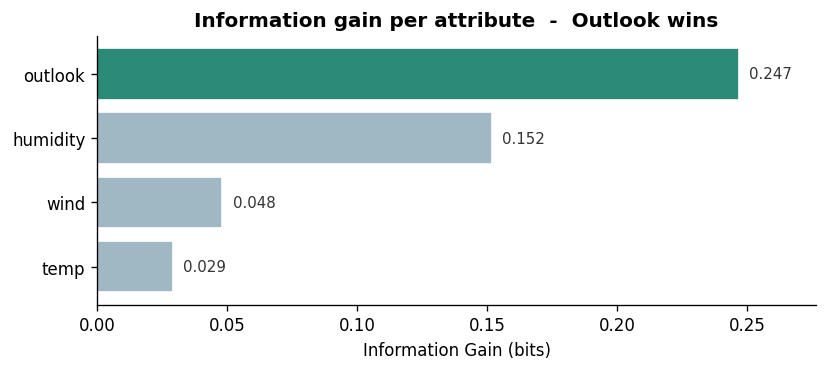

In [ ]:
# Information-gain bar chart
order = sorted(gains, key=gains.get)
vals = [gains[a] for a in order]
colors = ['#2b8a78' if a == best else '#9fb8c4' for a in order]

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(order, vals, color=colors, edgecolor='white')
for a, v in zip(order, vals):
    ax.text(v + 0.004, a, f'{v:.3f}', va='center', fontsize=9, color='#333')
ax.set_xlabel('Information Gain (bits)')
ax.set_title('Information gain per attribute  -  Outlook wins', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.margins(x=0.12)
plt.tight_layout(); plt.show()

## 4. The ID3 algorithm (recursive)

The tree is stored as nested dicts: `{attribute: {value: subtree_or_label}}`.

In [ ]:
def id3(df, target, attributes):
    labels = df[target]
    if labels.nunique() == 1:                       # pure node
        return labels.iloc[0]
    if not attributes:                              # no attributes -> majority
        return Counter(labels).most_common(1)[0][0]

    gains = {a: info_gain(df, a, target) for a in attributes}
    best = max(gains, key=gains.get)
    tree = {best: {}}
    remaining = [a for a in attributes if a != best]
    majority = Counter(labels).most_common(1)[0][0]
    for val, sub in df.groupby(best):
        tree[best][val] = (majority if len(sub) == 0
                           else id3(sub, target, remaining))
    return tree

tennis_tree = id3(tennis, target, attributes)
tennis_tree

{'outlook': {'overcast': 'Yes',
  'rain': {'wind': {'strong': 'No', 'weak': 'Yes'}},
  'sunny': {'humidity': {'high': 'No', 'normal': 'Yes'}}}}

In [ ]:
def print_tree(tree, indent=''):
    if not isinstance(tree, dict):
        print(indent + '--> ' + str(tree)); return
    attr = next(iter(tree))
    for val, sub in tree[attr].items():
        print(f'{indent}[{attr} = {val}]')
        print_tree(sub, indent + '    ')

print_tree(tennis_tree)

[outlook = overcast]
    --> Yes
[outlook = rain]
    [wind = strong]
        --> No
    [wind = weak]
        --> Yes
[outlook = sunny]
    [humidity = high]
        --> No
    [humidity = normal]
        --> Yes


## 5. Professional tree visualization (from scratch)

A polished renderer drawn with matplotlib - no external engine required. Each node shows its
sample count `n` and entropy `H`; leaves are colour-coded by predicted class.

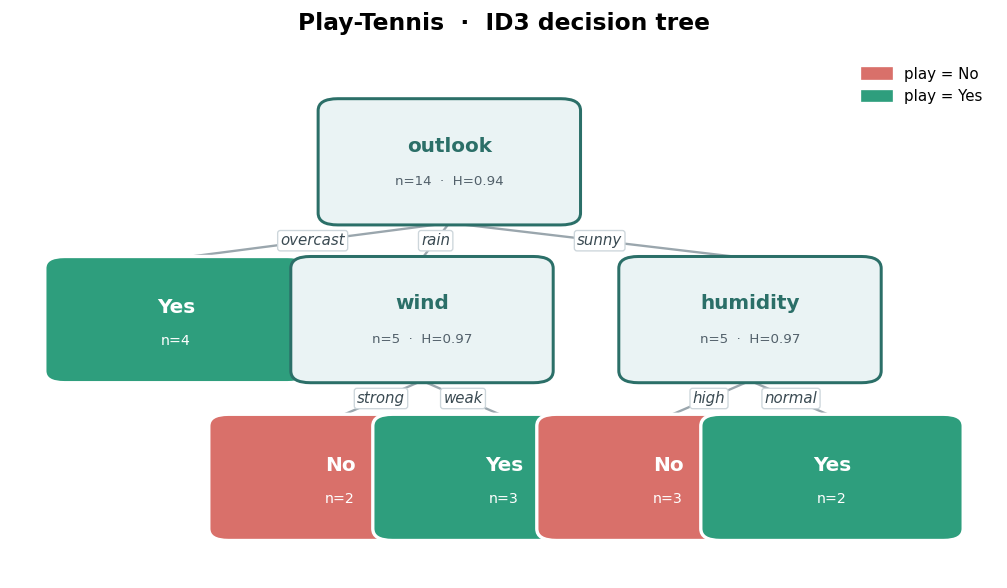

In [ ]:
# class -> fill colour (consistent across all custom plots)
CLASS_COLORS = {'Yes': '#2e9e7d', 'No': '#d9706a', 'yes': '#2e9e7d', 'no': '#d9706a'}
DECISION_FILL = '#eaf3f4'
DECISION_EDGE = '#2b6f68'

def _annotate(tree, df, target, depth, nodes, edges, leaf_x):
    """Walk tree + data together, recording layout + stats for each node."""
    nid = len(nodes)
    nodes.append(None)                      # reserve slot
    n = len(df)
    H = entropy(df[target])

    if not isinstance(tree, dict):          # leaf
        x = leaf_x[0]; leaf_x[0] += 1
        nodes[nid] = dict(id=nid, x=x, y=-depth, leaf=True,
                          cls=str(tree), n=n, H=H)
        return nid, x

    attr = next(iter(tree))
    child_xs = []
    for val, sub in tree[attr].items():
        sub_df = df[df[attr] == val]
        cid, cx = _annotate(sub, sub_df, target, depth + 1, nodes, edges, leaf_x)
        edges.append((nid, cid, str(val)))
        child_xs.append(cx)
    x = sum(child_xs) / len(child_xs)
    nodes[nid] = dict(id=nid, x=x, y=-depth, leaf=False,
                      attr=attr, n=n, H=H)
    return nid, x

def draw_tree_pro(tree, df, target, title='Decision Tree'):
    nodes, edges, leaf_x = [], [], [0]
    _annotate(tree, df, target, 0, nodes, edges, leaf_x)
    pos = {nd['id']: (nd['x'], nd['y'] * 1.6) for nd in nodes}

    n_leaves = leaf_x[0]
    depth = max(-nd['y'] for nd in nodes)
    fig, ax = plt.subplots(figsize=(max(8, n_leaves * 1.7), 1.6 + depth * 1.7))

    bw, bh = 0.78, 0.62                      # box half-width / half-height
    for pid, cid, lab in edges:              # edges behind nodes
        x1, y1 = pos[pid]; x2, y2 = pos[cid]
        ax.plot([x1, x2], [y1 - bh, y2 + bh], color='#9aa6ad', lw=1.4, zorder=1)
        ax.text((x1 + x2) / 2, (y1 + y2) / 2, lab, fontsize=9, ha='center',
                va='center', style='italic', color='#3a4a52', zorder=4,
                bbox=dict(boxstyle='round,pad=0.18', fc='white', ec='#cdd6db', lw=0.8))

    for nd in nodes:
        x, y = pos[nd['id']]
        if nd['leaf']:
            fill = CLASS_COLORS.get(nd['cls'], '#88aacc')
            ax.add_patch(FancyBboxPatch((x - bw, y - bh), 2 * bw, 2 * bh,
                         boxstyle='round,pad=0.02,rounding_size=0.12',
                         fc=fill, ec='white', lw=2, zorder=2))
            ax.text(x, y + 0.12, nd['cls'], ha='center', va='center',
                    fontsize=12, fontweight='bold', color='white', zorder=3)
            ax.text(x, y - 0.22, f'n={nd["n"]}', ha='center', va='center',
                    fontsize=8.5, color='white', zorder=3)
        else:
            ax.add_patch(FancyBboxPatch((x - bw, y - bh), 2 * bw, 2 * bh,
                         boxstyle='round,pad=0.02,rounding_size=0.12',
                         fc=DECISION_FILL, ec=DECISION_EDGE, lw=1.8, zorder=2))
            ax.text(x, y + 0.16, nd['attr'], ha='center', va='center',
                    fontsize=12, fontweight='bold', color=DECISION_EDGE, zorder=3)
            ax.text(x, y - 0.2, f'n={nd["n"]}  ·  H={nd["H"]:.2f}',
                    ha='center', va='center', fontsize=8, color='#52606a', zorder=3)

    classes = sorted({nd['cls'] for nd in nodes if nd['leaf']})
    handles = [mpatches.Patch(color=CLASS_COLORS.get(c, '#88aacc'),
                              label=f'{target} = {c}') for c in classes]
    ax.legend(handles=handles, loc='upper right', frameon=False, fontsize=9)

    ax.set_title(title, fontsize=14, fontweight='bold', pad=14)
    ax.set_xlim(-1, n_leaves); ax.set_ylim(-depth * 1.6 - 1, 1.1)
    ax.axis('off'); plt.tight_layout(); plt.show()

draw_tree_pro(tennis_tree, tennis, target, 'Play-Tennis  ·  ID3 decision tree')

## 6. Classify new examples

In [ ]:
def classify(tree, sample):
    if not isinstance(tree, dict):
        return tree
    attr = next(iter(tree))
    branch = tree[attr].get(sample.get(attr))
    return None if branch is None else classify(branch, sample)

new_day = {'outlook': 'sunny', 'temp': 'cool', 'humidity': 'high', 'wind': 'strong'}
print('Prediction for', new_day, '->', classify(tennis_tree, new_day))

preds = tennis.apply(lambda r: classify(tennis_tree, r.to_dict()), axis=1)
print('Training accuracy:', (preds == tennis['play']).mean())

Prediction for {'outlook': 'sunny', 'temp': 'cool', 'humidity': 'high', 'wind': 'strong'} -> No
Training accuracy: 1.0


## 7. Second dataset — "buys_computer"

The same `id3()` and `draw_tree_pro()` work unchanged.

[age = 31..40]
    --> yes
[age = <=30]
    [student = no]
        --> no
    [student = yes]
        --> yes
[age = >40]
    [credit_rating = excellent]
        --> no
    [credit_rating = fair]
        --> yes


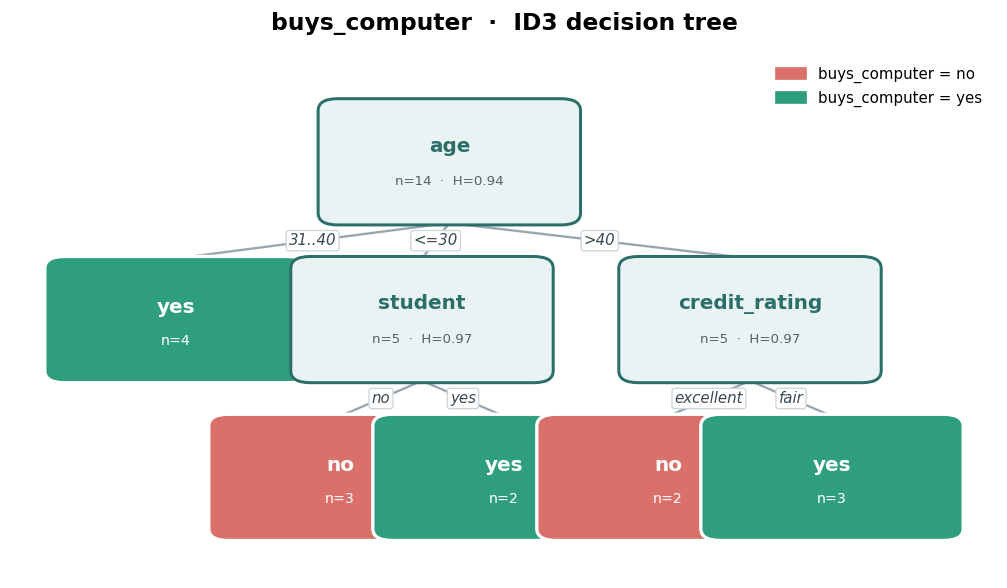

In [ ]:
buys = pd.DataFrame({
    'age':           ['<=30','<=30','31..40','>40','>40','>40','31..40',
                      '<=30','<=30','>40','<=30','31..40','31..40','>40'],
    'income':        ['high','high','high','medium','low','low','low',
                      'medium','low','medium','medium','medium','high','medium'],
    'student':       ['no','no','no','no','yes','yes','yes',
                      'no','yes','yes','yes','no','yes','no'],
    'credit_rating': ['fair','excellent','fair','fair','fair','excellent','excellent',
                      'fair','fair','fair','excellent','excellent','fair','excellent'],
    'buys_computer': ['no','no','yes','yes','yes','no','yes',
                      'no','yes','yes','yes','yes','yes','no'],
})

b_target, b_attrs = 'buys_computer', ['age', 'income', 'student', 'credit_rating']
buys_tree = id3(buys, b_target, b_attrs)
print_tree(buys_tree)
draw_tree_pro(buys_tree, buys, b_target, 'buys_computer  ·  ID3 decision tree')

## 8. Cross-check with scikit-learn

scikit-learn needs numeric input, so we one-hot encode. With `criterion='entropy'` it uses the
same information-gain split rule, so it should produce an equivalent tree.

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text, export_graphviz

X = pd.get_dummies(tennis[attributes])
y = tennis[target]

clf = DecisionTreeClassifier(criterion='entropy', random_state=0)
clf.fit(X, y)
print('sklearn training accuracy:', clf.score(X, y))
print()
print(export_text(clf, feature_names=list(X.columns)))

sklearn training accuracy: 1.0

|--- outlook_overcast <= 0.50
|   |--- humidity_normal <= 0.50
|   |   |--- outlook_rain <= 0.50
|   |   |   |--- class: No
|   |   |--- outlook_rain >  0.50
|   |   |   |--- wind_strong <= 0.50
|   |   |   |   |--- class: Yes
|   |   |   |--- wind_strong >  0.50
|   |   |   |   |--- class: No
|   |--- humidity_normal >  0.50
|   |   |--- wind_weak <= 0.50
|   |   |   |--- temp_cool <= 0.50
|   |   |   |   |--- class: Yes
|   |   |   |--- temp_cool >  0.50
|   |   |   |   |--- class: No
|   |   |--- wind_weak >  0.50
|   |   |   |--- class: Yes
|--- outlook_overcast >  0.50
|   |--- class: Yes



### 8a. Built-in `plot_tree` (entropy, sample proportions, class colours)

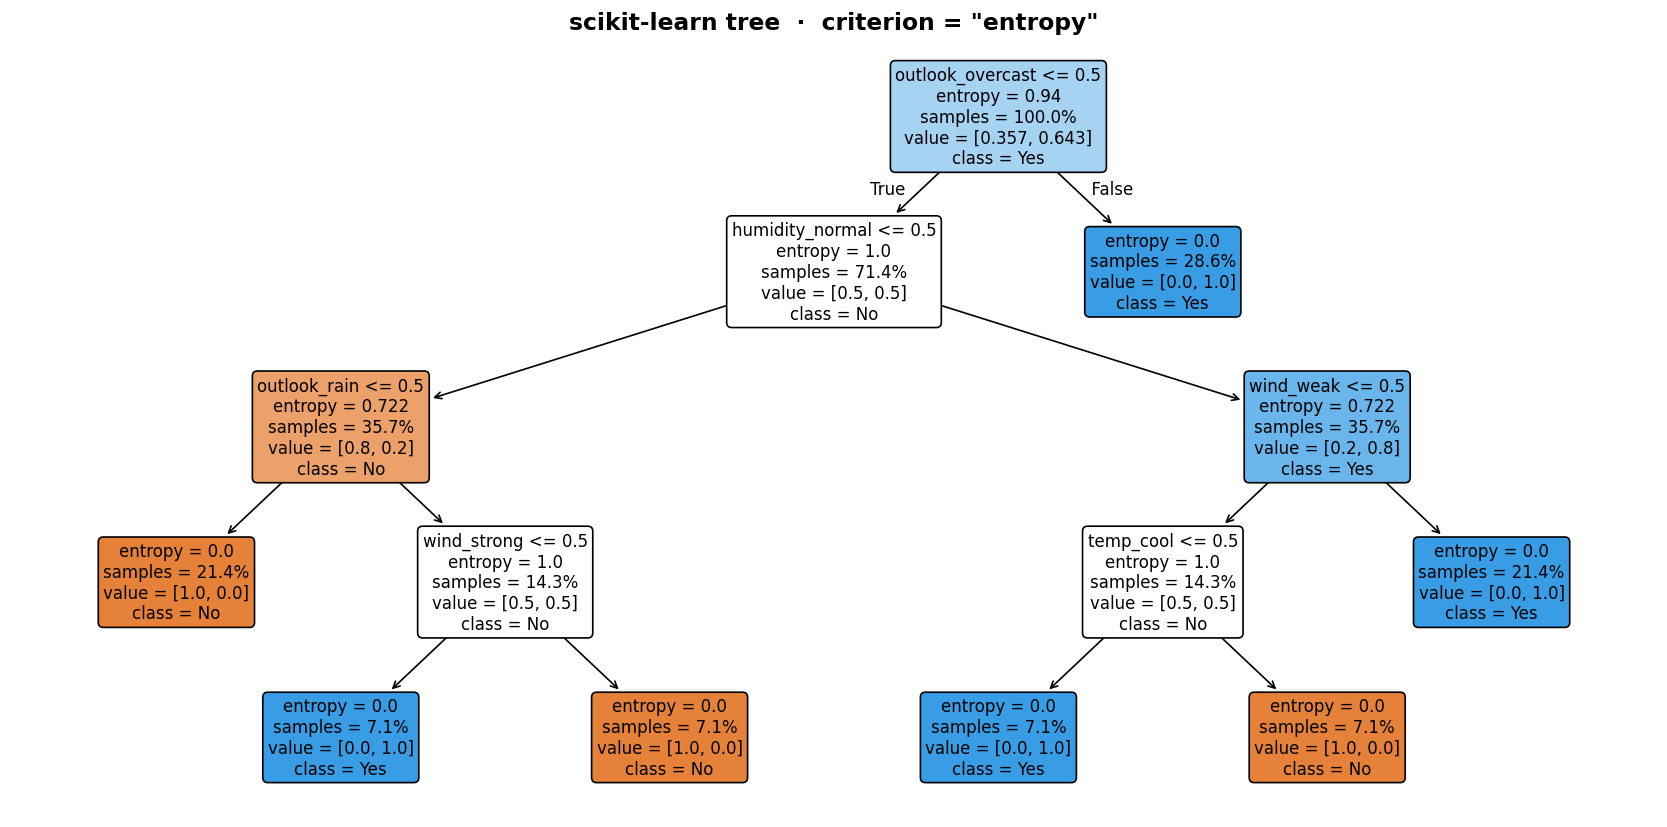

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))
plot_tree(clf,
          feature_names=X.columns,
          class_names=clf.classes_,
          filled=True, rounded=True, proportion=True,
          impurity=True, fontsize=10, ax=ax)
ax.set_title('scikit-learn tree  ·  criterion = "entropy"', fontweight='bold', fontsize=14)
plt.tight_layout(); plt.show()

### 8b. Graphviz render (publication quality)

`export_graphviz` + the Graphviz `dot` engine give the cleanest layout. Rendered to PNG and
embedded directly in the notebook.

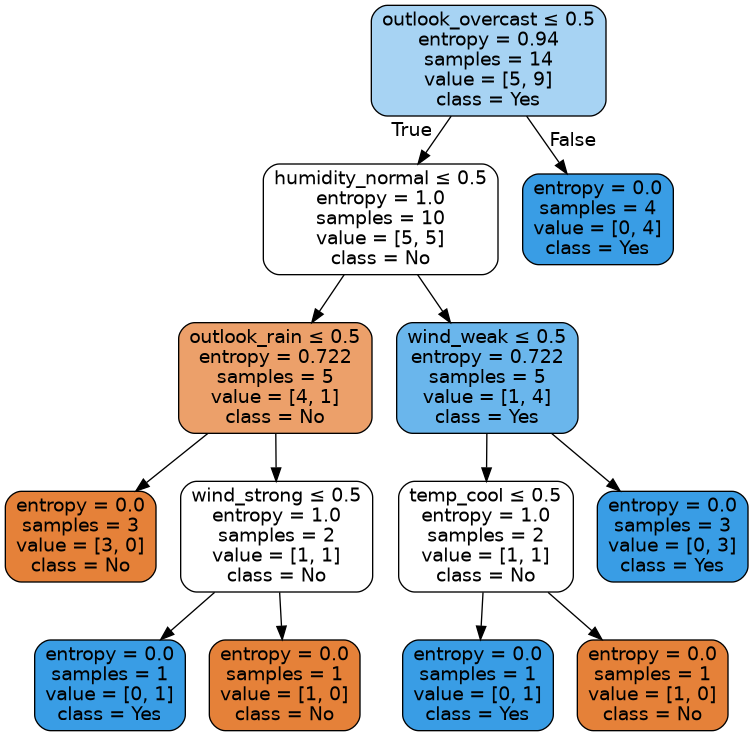

In [ ]:
import graphviz
from IPython.display import Image, display

dot = export_graphviz(
    clf, out_file=None,
    feature_names=X.columns, class_names=clf.classes_,
    filled=True, rounded=True, special_characters=True,
    impurity=True, proportion=False,
)
src = graphviz.Source(dot)
display(Image(src.pipe(format='png')))

### 8c. Feature importances

How much each one-hot feature contributed to the splits.

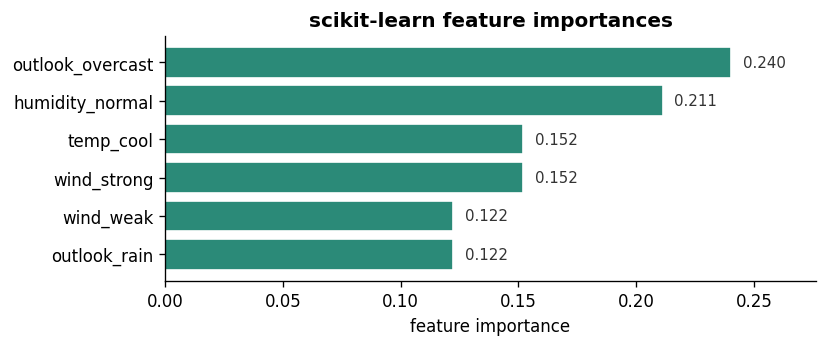

In [ ]:
imp = pd.Series(clf.feature_importances_, index=X.columns)
imp = imp[imp > 0].sort_values()

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(imp.index, imp.values, color='#2b8a78', edgecolor='white')
for name, v in imp.items():
    ax.text(v + 0.005, name, f'{v:.3f}', va='center', fontsize=9, color='#333')
ax.set_xlabel('feature importance')
ax.set_title('scikit-learn feature importances', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.margins(x=0.15)
plt.tight_layout(); plt.show()